In [1]:
import os
import numpy as np
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
FS = 128
EPOCH_SEC = 8
BAND = (0.5, 45)

ROOT = "FINAL_DATASET"
HEALTHY_FOLDERS = ["Healthy/eyes-closed"]
AD_FOLDER = "Alzehiemers/eyes-closed"

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

CHANNELS = [
    "Fp1","Fp2","F3","F4","F7","F8","Fz",
    "C3","C4","Cz",
    "P3","P4","Pz",
    "T3","T4","T5","T6",
    "O1","O2"
]

Using device: mps


In [3]:
def butter_bandpass(low, high, fs, order=6):
    nyq = 0.5 * fs
    return butter(order, [low/nyq, high/nyq], btype="band")

def bandpass_filter(eeg):
    b, a = butter_bandpass(*BAND, FS)
    eeg = filtfilt(b, a, eeg, axis=0)
    eeg = (eeg - np.mean(eeg, axis=0)) / (np.std(eeg, axis=0) + 1e-8)
    return eeg.astype(np.float32)

In [4]:
def epoch_signal(eeg):
    samples = FS * EPOCH_SEC
    epochs = []

    for i in range(0, eeg.shape[0], samples):
        ep = eeg[i:i+samples]
        if ep.shape[0] == samples:
            epochs.append(ep)

    return np.array(epochs)

In [5]:
def load_patient(folder):
    signals = []

    for ch in CHANNELS:
        path = os.path.join(folder, f"{ch}.txt")

        if not os.path.exists(path):
            return None

        signals.append(np.loadtxt(path))

    return np.stack(signals, axis=1)

In [6]:
def load_all():
    X, y = [], []

    healthy_base = os.path.join(ROOT)

    for folder in HEALTHY_FOLDERS:
        base = os.path.join(healthy_base, folder)

        if not os.path.exists(base):
            continue

        for patient in os.listdir(base):
            pdir = os.path.join(base, patient)

            eeg = load_patient(pdir)
            if eeg is None:
                continue

            eeg = bandpass_filter(eeg)
            epochs = epoch_signal(eeg)

            if len(epochs) > 0:
                X.append(epochs)
                y.append(0)

    ad_base = os.path.join(ROOT, AD_FOLDER)

    for patient in os.listdir(ad_base):
        pdir = os.path.join(ad_base, patient)

        eeg = load_patient(pdir)
        if eeg is None:
            continue

        eeg = bandpass_filter(eeg)
        epochs = epoch_signal(eeg)

        if len(epochs) > 0:
            X.append(epochs)
            y.append(1)

    print("Loaded", len(X), "subjects")
    return X, np.array(y)

In [7]:
def prepare_cldnn_data(Xp, yp, max_epochs_per_subject=50, max_healthy=300):
    healthy_X, ad_X = [], []

    for i in range(len(Xp)):
        epochs = Xp[i]

        if len(epochs) > max_epochs_per_subject:
            idx = np.random.choice(len(epochs), max_epochs_per_subject, replace=False)
            epochs = epochs[idx]

        for ep in epochs:
            if yp[i] == 0:
                healthy_X.append(ep.T)
            else:
                ad_X.append(ep.T)

    healthy_X = np.array(healthy_X)
    ad_X = np.array(ad_X)

    if len(healthy_X) > max_healthy:
        idx = np.random.choice(len(healthy_X), max_healthy, replace=False)
        healthy_X = healthy_X[idx]

    X = np.concatenate([healthy_X, ad_X])
    y = np.array([0]*len(healthy_X) + [1]*len(ad_X))

    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

In [8]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

In [10]:
class CLDNN_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(len(CHANNELS), 64, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.4)

        self.lstm = nn.LSTM(128, 64, batch_first=True, bidirectional=True)
        self.attention = Attention(128)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))

        x = self.dropout(x)
        x = x.permute(0, 2, 1)

        x, _ = self.lstm(x)
        x = self.attention(x)

        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [11]:
def loso_split(Xp):
    for i in range(len(Xp)):
        train_idx = [j for j in range(len(Xp)) if j != i]
        test_idx = [i]
        yield train_idx, test_idx

In [12]:
def train_model(Xp, yp):
    print("===== TRAINING CLDNN =====")

    # Prepare complete dataset
    X_train, y_train = prepare_cldnn_data(
        Xp,
        yp
    )

    print("Training distribution:", np.bincount(y_train))
    print("Total training samples:", len(y_train))

    # Dataset and DataLoader
    dataset = EEGDataset(X_train, y_train)

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=True
    )

    # Create model
    model = CLDNN_Strong().to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    # Training
    for epoch in range(8):

        model.train()
        losses = []

        for data, target in loader:

            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(data)

            loss = criterion(output, target)

            loss.backward()

            optimizer.step()

            losses.append(loss.item())

        print(
            f"Epoch {epoch + 1}/8 "
            f"Loss: {np.mean(losses):.6f}"
        )

    # =====================================================
    # SAVE TRAINED MODEL IN ROOT FOLDER
    # =====================================================

    model_path = "CLDNN_Strong_best.pth"

    torch.save(
        model.state_dict(),
        model_path
    )

    print("\n================================")
    print("Training completed.")
    print(f"Model saved at: {model_path}")
    print("================================")

    return model

In [13]:
Xp, yp = load_all()

if len(Xp) == 0:
    print("No data found")
else:
    model = train_model(Xp, yp)

Loaded 232 subjects
===== TRAINING CLDNN =====
Training distribution: [ 300 1868]
Total training samples: 2168
Epoch 1/8 Loss: 0.305074
Epoch 2/8 Loss: 0.184591
Epoch 3/8 Loss: 0.177996
Epoch 4/8 Loss: 0.171423
Epoch 5/8 Loss: 0.169941
Epoch 6/8 Loss: 0.164394
Epoch 7/8 Loss: 0.156569
Epoch 8/8 Loss: 0.155786

Training completed.
Model saved at: CLDNN_Strong_best.pth


===== FINAL EVALUATION (CLDNN) =====
Subject 1/232 | Actual: 0 | Predicted: 0
Subject 2/232 | Actual: 0 | Predicted: 0
Subject 3/232 | Actual: 0 | Predicted: 1
Subject 4/232 | Actual: 0 | Predicted: 1
Subject 5/232 | Actual: 0 | Predicted: 0
Subject 6/232 | Actual: 0 | Predicted: 1
Subject 7/232 | Actual: 0 | Predicted: 0
Subject 8/232 | Actual: 0 | Predicted: 0
Subject 9/232 | Actual: 0 | Predicted: 0
Subject 10/232 | Actual: 0 | Predicted: 0
Subject 11/232 | Actual: 0 | Predicted: 0
Subject 12/232 | Actual: 0 | Predicted: 0
Subject 13/232 | Actual: 0 | Predicted: 0
Subject 14/232 | Actual: 0 | Predicted: 0
Subject 15/232 | Actual: 0 | Predicted: 0
Subject 16/232 | Actual: 0 | Predicted: 0
Subject 17/232 | Actual: 0 | Predicted: 1
Subject 18/232 | Actual: 0 | Predicted: 1
Subject 19/232 | Actual: 0 | Predicted: 1
Subject 20/232 | Actual: 0 | Predicted: 1
Subject 21/232 | Actual: 0 | Predicted: 1
Subject 22/232 | Actual: 0 | Predicted: 1
Subject 23/232 | Actual: 0 | Predicted: 0
Subjec

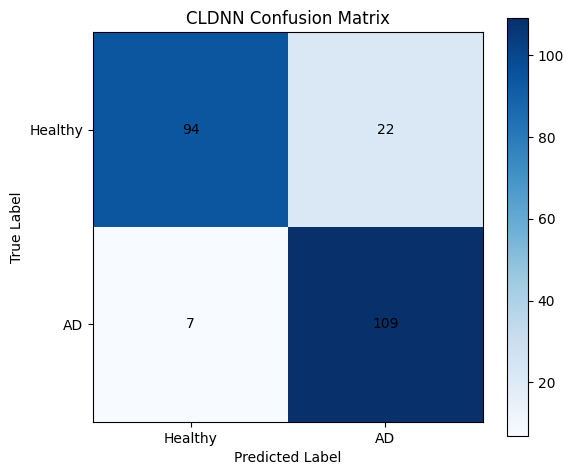

In [14]:
# ===== CELL 14: CLDNN FINAL EVALUATION =====

import numpy as np
import matplotlib.pyplot as plt

print("===== FINAL EVALUATION (CLDNN) =====")

model.eval()

total_preds = []
total_true = []

# Evaluate each subject
for i in range(len(Xp)):

    # Prepare subject data
    data_np = np.array([
        ep.T for ep in Xp[i]
    ])

    data = torch.tensor(
        data_np,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        output = model(data)

        probs = torch.softmax(
            output,
            dim=1
        ).cpu().numpy()

    # Average probabilities across epochs/windows
    mean_probs = np.mean(probs, axis=0)

    # Same threshold you used previously
    pred = 1 if mean_probs[1] > 0.6 else 0

    total_preds.append(pred)
    total_true.append(yp[i])

    print(
        f"Subject {i + 1}/{len(Xp)} | "
        f"Actual: {yp[i]} | "
        f"Predicted: {pred}"
    )

# Convert to numpy
total_preds = np.array(total_preds)
total_true = np.array(total_true)

print("\nTotal Subjects:", len(total_preds))

# =====================================================
# CONFUSION MATRIX
# =====================================================

tp = np.sum(
    (total_preds == 1) &
    (total_true == 1)
)

tn = np.sum(
    (total_preds == 0) &
    (total_true == 0)
)

fp = np.sum(
    (total_preds == 1) &
    (total_true == 0)
)

fn = np.sum(
    (total_preds == 0) &
    (total_true == 1)
)

cm = np.array([
    [tn, fp],
    [fn, tp]
])

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed:")
print("TN (Healthy → Healthy):", tn)
print("FP (Healthy → AD):", fp)
print("FN (AD → Healthy):", fn)
print("TP (AD → AD):", tp)

# =====================================================
# METRICS
# =====================================================

accuracy = (tp + tn) / len(total_preds)

precision = tp / (tp + fp + 1e-8)

recall = tp / (tp + fn + 1e-8)

specificity = tn / (tn + fp + 1e-8)

f1 = (
    2 * precision * recall /
    (precision + recall + 1e-8)
)

print("\n===== METRICS =====")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall / Sensitivity:",
    round(recall, 4)
)

print(
    "Specificity:",
    round(specificity, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

# =====================================================
# CONFUSION MATRIX PLOT
# =====================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title("CLDNN Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Healthy", "AD"]
)

plt.yticks(
    [0, 1],
    ["Healthy", "AD"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()